In [1]:
# визуализация изображения
# фрактала Кристалл, построенного
# в соответствие с алгоритмом РСИФ

# Ячейка № 1

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение библиотеки numpy
import numpy as np


In [2]:
# Ячейка № 2

# инициализация генератора случайных чисел
np.random.seed()


# задание функции,возвращающей значения
# чисел из диапазона: 0, 1,..., Basis^Power
# (Basis, Power -- числа в десятичной
# системе счисление) в системе
# счисления по основанию Basis
def Rule(Basis, Power):
    # входные переменные:
    # Basis - основание системы счисления
    # Power - показатель степени
    Tmp_list = []

    for i in range(Basis**Power + 1):
        Str_Digit = ""
        Number = i
        while Number > 0:
            Str_Digit = str(Number % Power) + Str_Digit
            Number = Number // Power
        if i == 0:
            Str_Digit = "0"
            Tmp_list.append("0")
        else:
            Tmp_list.append(Str_Digit)

    return Tmp_list

In [3]:
# Ячейка № 3

# задание функции, возвращающей изображение
# фрактала Кристалл с помощью
# системы итерированных функций


def Cristal_RSIF(N_Iter, N_Trial):
    # N_Iter - порядок ковра
    # N_Trial - число испытаний
    #           метода Монте-Карло

    Flag = 0
    while Flag == 0:
        Tmp_X = np.random.uniform(0, 1)
        Tmp_Y = np.sqrt(3) / 2 * np.random.uniform(0, 1)
        if (
            -np.sqrt(3) * Tmp_X + Tmp_Y <= 0
            and np.sqrt(3) * Tmp_X + Tmp_Y - np.sqrt(3) <= 0
        ):
            x0 = Tmp_X
            y0 = Tmp_Y
            Flag = 1

    Cod_list = Rule(4, N_Iter)

    A1 = np.array([[0.255, 0.0], [0.0, 0.2550]])
    A2 = np.array([[0.255, 0.0], [0.0, 0.255]])
    A3 = np.array([[0.255, 0.0], [0.0, 0.255]])
    A4 = np.array([[0.37, -0.642], [0.642, 0.37]])
    a1 = np.array([0.3726, 0.6714])
    a2 = np.array([0.1146, 0.2232])
    a3 = np.array([0.6306, 0.2232])
    a4 = np.array([0.6356, -0.0061])

    F = plt.figure(figsize=(8, 8))
    F.add_subplot()

    plt.axis("equal")
    plt.axis("off")
    Draw_Cristal(N_Iter, N_Trial, x0, y0, A1, A2, A3, A4, a1, a2, a3, a4, Cod_list)

In [4]:
# Ячейка № 4

# задание функции, возвращающей
# результат аффинных преобразований
# координат точек
def Affin_Transform(X, Y, A, a):
    # входные переменные:
    # X, Y - координаты точки
    # A, a - значения параметров
    #        аффинных преобразований

    R = np.array([X, Y])
    R = A.dot(R) + a
    x_Tr = R[0]
    y_Tr = R[1]
    return x_Tr, y_Tr

In [5]:
# Ячейка № 5

# задание функции, возвращающей
# изображение фрактала Кристалл
def Draw_Cristal(N_Iter, N_Trial, x0, y0, A1, A2, A3, A4, a1, a2, a3, a4, Cod_list):
    # входные переменные:
    # N_Iter - порядок фрактала
    # N_Trial - число независимых испытаний
    #           метода Монте-Карло
    # x0, y0 - координаты начальной точки
    #  A1, A2, A3, A4,
    # a1, a2, a3, a4 - параметры аффинных преобразований

    for n in range(4**N_Iter):
        X1 = np.zeros(N_Trial)
        Y1 = np.zeros(N_Trial)
        X = x0
        Y = y0
        for m in range(N_Trial):
            N_R = np.random.randint(0, len(Cod_list) - 1)
            Tmp = Cod_list[N_R]
            Len_Tmp = len(Tmp)
            for j in range(Len_Tmp):
                if Tmp[j] == "0":
                    [X, Y] = Affin_Transform(X, Y, A1, a1)
                if Tmp[j] == "1":
                    [X, Y] = Affin_Transform(X, Y, A2, a2)
                if Tmp[j] == "2":
                    [X, Y] = Affin_Transform(X, Y, A3, a3)
                if Tmp[j] == "3":
                    [X, Y] = Affin_Transform(X, Y, A4, a4)
            X1[m] = X
            Y1[m] = Y

        plt.plot(X1, Y1, ".k", markersize=0.1)


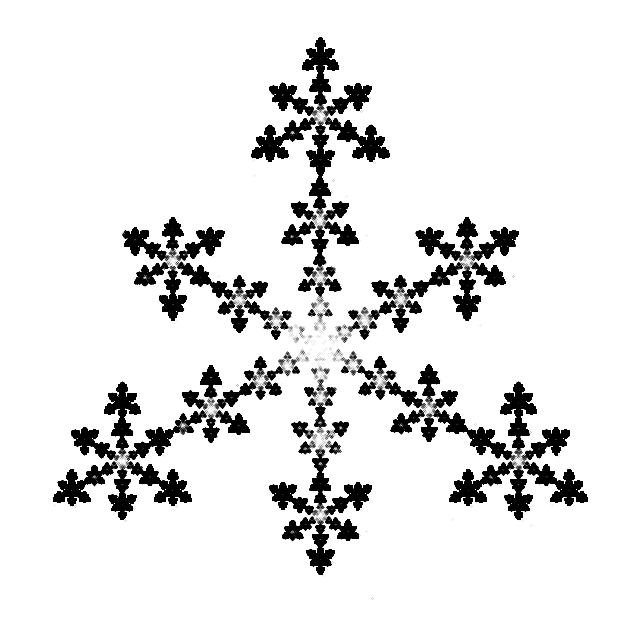

In [6]:
# Ячейка № 6

# визуализация изображения
# фрактала кристал пятого порядка
# в соответствие с алгоритмом РСИФ

Cristal_RSIF(4, 5 * 10**4)